# 04 — Neural Network with Keras/TensorFlow (Tabular Data)

**Goal:** now we use
TensorFlow/Keras to build a *real* neural network classifier and train it on all three dataset
sizes (small/medium/large), the same way we did for the classical models in Notebook 02. This gives
us the deep-learning half of our central research question: **does the neural network need more
data than classical ML to reach the same or better performance?**

**Concepts applied here:** L2 regularization, Dropout, Batch Normalization, the Adam
optimizer, early stopping, and a small hyperparameter search

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [2]:
data = joblib.load("../data/processed/tabular_data.joblib")
subsets = data["subsets"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]
n_features = X_val.shape[1]
print("n_features:", n_features)

n_features: 108


## 1. Model-building function

Parametrized so we can reuse it for the baseline runs and for the hyperparameter sweep later.
Architecture: two hidden Dense layers with ReLU, optional BatchNorm and Dropout after each, L2
weight regularization, Sigmoid output for binary classification.

In [3]:
def build_model(n_features, hidden_units=(64, 32), dropout_rate=0.2, l2_reg=0.001, learning_rate=1e-3):
    reg = keras.regularizers.l2(l2_reg) if l2_reg > 0 else None
    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features,)))
    for units in hidden_units:
        model.add(layers.Dense(units, kernel_regularizer=reg))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation("relu"))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

## 2. Train + evaluate helper

Uses `EarlyStopping` (stop training once validation loss stops improving, restore the best weights)
— this saves us from having to hand-pick the number of epochs.

In [4]:
def train_and_evaluate(X_train, y_train, X_val, y_val, **model_kwargs):
    model = build_model(X_train.shape[1], **model_kwargs)
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True
    )
    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=150,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0,
    )
    train_time = time.time() - t0

    val_probs = model.predict(X_val, verbose=0).ravel()
    val_preds = (val_probs > 0.5).astype(int)
    metrics = {
        "val_accuracy": accuracy_score(y_val, val_preds),
        "val_precision": precision_score(y_val, val_preds, zero_division=0),
        "val_recall": recall_score(y_val, val_preds, zero_division=0),
        "val_f1": f1_score(y_val, val_preds, zero_division=0),
        "val_roc_auc": roc_auc_score(y_val, val_probs),
        "train_time_sec": train_time,
        "n_epochs_ran": len(history.history["loss"]),
    }
    return model, history, metrics

## 3. Baseline NN on each dataset size (small / medium / large)

In [5]:
nn_rows = []
nn_models = {}
nn_histories = {}

for size_name, (X_train, y_train) in subsets.items():
    model, history, metrics = train_and_evaluate(X_train, y_train, X_val, y_val)
    nn_models[size_name] = model
    nn_histories[size_name] = history
    row = {"model": "NeuralNet_Keras", "dataset_size_name": size_name, "n_train": X_train.shape[0], **metrics}
    nn_rows.append(row)
    print(f"{size_name} (n={X_train.shape[0]}): val_f1={metrics['val_f1']:.3f}, "
          f"val_acc={metrics['val_accuracy']:.3f}, epochs={metrics['n_epochs_ran']}, "
          f"time={metrics['train_time_sec']:.1f}s")

nn_results = pd.DataFrame(nn_rows)
nn_results

small (n=800): val_f1=0.624, val_acc=0.837, epochs=29, time=10.1s
medium (n=6000): val_f1=0.645, val_acc=0.849, epochs=28, time=14.8s
large (n=34187): val_f1=0.641, val_acc=0.849, epochs=28, time=44.9s


,model,dataset_size_name,n_train,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,train_time_sec,n_epochs_ran
0,NeuralNet_Keras,small,800,0.837336,0.698233,0.563605,0.623737,0.885408,10.095713,29
1,NeuralNet_Keras,medium,6000,0.848799,0.735230,0.575014,0.645327,0.903583,14.807698,28
2,NeuralNet_Keras,large,34187,0.848663,0.741742,0.563605,0.640519,0.907307,44.883202,28


## 4. Training curves — checking for overfitting

For each dataset size, we plot training vs. validation loss over epochs. A widening gap between the
two curves is the visual signature of overfitting (high variance) — exactly what dropout, L2, and
batch norm are meant to fight.

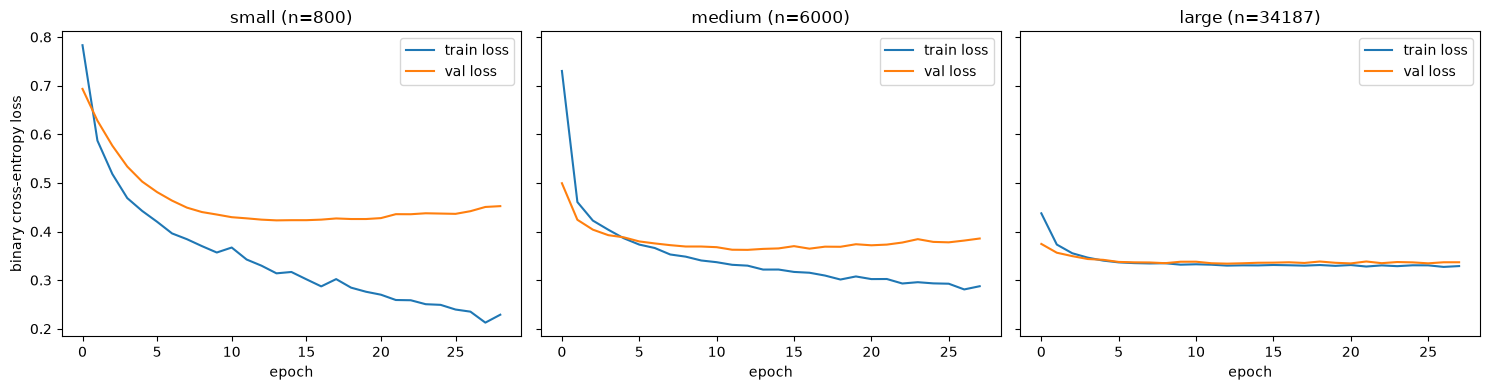

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, size_name in zip(axes, ["small", "medium", "large"]):
    h = nn_histories[size_name].history
    ax.plot(h["loss"], label="train loss")
    ax.plot(h["val_loss"], label="val loss")
    ax.set_title(f"{size_name} (n={subsets[size_name][0].shape[0]})")
    ax.set_xlabel("epoch")
    ax.legend()
axes[0].set_ylabel("binary cross-entropy loss")
plt.tight_layout()
plt.savefig("../results/figures/nn_training_curves.png", dpi=150)
plt.show()

## 5. Small hyperparameter sweep (on the `small` subset — where tuning matters most)

We vary dropout rate and L2 strength and see which combination generalizes best when data is
scarce.

In [7]:
X_small, y_small = subsets["small"]

sweep_configs = [
    {"dropout_rate": 0.0, "l2_reg": 0.0},
    {"dropout_rate": 0.3, "l2_reg": 0.0},
    {"dropout_rate": 0.0, "l2_reg": 0.01},
    {"dropout_rate": 0.3, "l2_reg": 0.01},
    {"dropout_rate": 0.5, "l2_reg": 0.001},
]

sweep_rows = []
for cfg in sweep_configs:
    _, _, metrics = train_and_evaluate(X_small, y_small, X_val, y_val, **cfg)
    sweep_rows.append({**cfg, **metrics})
    print(cfg, "-> val_f1:", round(metrics["val_f1"], 3))

sweep_df = pd.DataFrame(sweep_rows).sort_values("val_f1", ascending=False)
sweep_df

{'dropout_rate': 0.0, 'l2_reg': 0.0} -> val_f1: 0.565
{'dropout_rate': 0.3, 'l2_reg': 0.0} -> val_f1: 0.624
{'dropout_rate': 0.0, 'l2_reg': 0.01} -> val_f1: 0.479
{'dropout_rate': 0.3, 'l2_reg': 0.01} -> val_f1: 0.593
{'dropout_rate': 0.5, 'l2_reg': 0.001} -> val_f1: 0.631


,dropout_rate,l2_reg,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,train_time_sec,n_epochs_ran
4,0.5,0.001,0.839929,0.703081,0.572732,0.631248,0.888165,13.603760,45
1,0.3,0.000,0.836927,0.695652,0.565887,0.624096,0.885035,10.111174,31
3,0.3,0.010,0.836381,0.732773,0.497433,0.592593,0.878326,13.365704,42
0,0.0,0.000,0.831878,0.741427,0.456361,0.564972,0.869798,8.716502,25
2,0.0,0.010,0.816457,0.746377,0.352539,0.478884,0.813621,11.051907,36


## 6. Save results for the final comparison notebook

In [8]:
nn_results.to_csv("../results/nn_metrics.csv", index=False)
sweep_df.to_csv("../results/nn_hyperparameter_sweep.csv", index=False)
print("Saved.")

Saved.


## Summary

We trained a regularized, batch-normalized feedforward neural network on the same three training
set sizes as the classical models, diagnosed overfitting via training curves, and ran a small
hyperparameter sweep showing how regularization strength should adapt to dataset size.